# Cyclic CIFAR-100 for MTF: where factorization should and should not pay

Companion experiment for the TTCL paper (cyclic Split-MNIST counterpart on CIFAR-100,
frozen ViT-B/16 features). Three parts:

| Part | Stream | Question | Predicted outcome (pre-registered below) |
|---|---|---|---|
| **0** | cyclic Split-MNIST (paper Table 2 protocol) | do train-nothing memory classifiers match MTF? | NCM ≈ class-centroid MTF; 1-NN ≈ exemplar MTF |
| **A** | cyclic CIFAR-100, superclass-pair contexts, **fixed label meanings**, mixed per-sample test | anchor: does MTF beat its own router used as a classifier? does recognition hold the library at K\*? | MTF ≈ router-as-classifier (±2 pts) |
| **B** | cyclic CIFAR-100, **same images, context-dependent labels**, prequential (predict, then see label) | the trap: does recognising a returning context pay, by the predicted amount? | payoff grows with conflict ρ; MTF ≫ context-free at ρ=1; ≈ at ρ=0 |

**Why Part B and not just Part A.** If the pooled label is a fixed function of the frozen
features, a single memory classifier (kNN/SLDA) learns it without forgetting, and MTF can at
best tie it on accuracy. MTF can win on accuracy only when the pooled mapping is *not* a
function of φ(x) (conflict across contexts) — then context must be inferred from the stream.
Part B varies the conflict fraction ρ and the run length L that control this.

**Run modes** (`CYCLIC_RUN_MODE` env var or edit Cell 1): `SMOKE` (minutes, wiring only),
`DEV` (reduced grid), `FULL` (the paper run: 5 seeds, full grid). Results checkpoint per
(part, config, seed) under `RESULTS_DIR/<mode>/`; re-running skips completed units.

**Features.** Cell 2 loads `FEAT_DIR/cifar100_vit_b16_<WEIGHTS>.pt` if present, otherwise
extracts it (GPU recommended for extraction only; everything else runs on CPU):
`WEIGHTS='timm_default'` = `timm` `vit_base_patch16_224` default pretrained weights (the
TTCL harness); `'jx_github'` = the original Google in21k→in1k checkpoint from timm's GitHub
release (used for the DEV run that accompanies this notebook). Same preprocessing as the
TTCL harness: bit-faithful PIL bicubic 32→224, CIFAR-100 mean/std, clean views only.

In [1]:
# ============================================================
# Cell 1: Config
# ============================================================
import os, json, time, math, random, gc, pickle, hashlib, gzip, urllib.request
from collections import deque, defaultdict
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

RUN_MODE    = os.environ.get('CYCLIC_RUN_MODE', 'FULL')        # 'SMOKE' | 'DEV' | 'FULL'
FEAT_DIR    = os.environ.get('CYCLIC_FEAT_DIR', './cyclic_cifar100_cache')
RESULTS_DIR = os.environ.get('CYCLIC_RESULTS_DIR', './cyclic_cifar100_results')
CIFAR_ROOT  = os.environ.get('CYCLIC_CIFAR_ROOT', './data')    # holds cifar-100-python/ (downloaded if absent)
WEIGHTS     = os.environ.get('CYCLIC_WEIGHTS', 'timm_default') # 'timm_default' | 'jx_github'
MNIST_ROOT  = os.environ.get('CYCLIC_MNIST_ROOT', './data/mnist')
RUN_PART0, RUN_PART_A, RUN_PART_B = True, True, True

MODE = {
  'SMOKE': dict(A_SEEDS=[1], A_CYCLES=2, A_PRES_N=1000,
                B_SEEDS=[1], B_T=1500, B_RHOS=[0.0, 1.0], B_LS=[50], B_SEM_LS=[50], M0_SEEDS=[1]),
  'DEV':   dict(A_SEEDS=[1, 2], A_CYCLES=4, A_PRES_N=1000,
                B_SEEDS=[1, 2], B_T=6000, B_RHOS=[0.0, 1.0], B_LS=[20, 500], B_SEM_LS=[100], M0_SEEDS=[1, 2]),
  'FULL':  dict(A_SEEDS=[1, 2, 3, 4, 5], A_CYCLES=4, A_PRES_N=1000,
                B_SEEDS=[1, 2, 3, 4, 5], B_T=12000, B_RHOS=[0.0, 0.25, 0.5, 1.0], B_LS=[20, 100, 500],
                B_SEM_LS=[20, 100, 500], M0_SEEDS=[1, 2, 3, 4, 5]),
}[RUN_MODE]
globals().update(MODE)

OUT = os.path.join(RESULTS_DIR, RUN_MODE); os.makedirs(OUT, exist_ok=True); os.makedirs(FEAT_DIR, exist_ok=True)
torch.set_num_threads(max(1, os.cpu_count() or 1))
CPU = torch.device('cpu')

def save_json(obj, name):
    with open(os.path.join(OUT, name), 'w') as fh: json.dump(obj, fh, indent=1)
def load_json(name, default=None):
    p = os.path.join(OUT, name)
    return json.load(open(p)) if os.path.exists(p) else default
print(f'RUN_MODE={RUN_MODE}  WEIGHTS={WEIGHTS}  results -> {OUT}')
print(MODE)

RUN_MODE=FULL  WEIGHTS=timm_default  results -> ./cyclic_cifar100_results/FULL
{'A_SEEDS': [1, 2, 3, 4, 5], 'A_CYCLES': 4, 'A_PRES_N': 1000, 'B_SEEDS': [1, 2, 3, 4, 5], 'B_T': 12000, 'B_RHOS': [0.0, 0.25, 0.5, 1.0], 'B_LS': [20, 100, 500], 'B_SEM_LS': [20, 100, 500], 'M0_SEEDS': [1, 2, 3, 4, 5]}


In [2]:
# ============================================================
# Cell 2: Frozen ViT-B/16 features (load cache or extract once)
# ============================================================
FEAT_FILE = os.path.join(FEAT_DIR, f'cifar100_vit_b16_{WEIGHTS}.pt')

def _cifar_split(split):
    p = os.path.join(CIFAR_ROOT, 'cifar-100-python', split)
    if not os.path.exists(p):
        import torchvision
        torchvision.datasets.CIFAR100(CIFAR_ROOT, train=True, download=True)
    with open(p, 'rb') as fh:
        return pickle.load(fh, encoding='latin1')

def _pil_bicubic_matrix(n_in=32, n_out=224):
    a, scale, support = -0.5, n_in / n_out, 2.0
    def k(x):
        x = abs(x)
        if x < 1: return (a + 2) * x**3 - (a + 3) * x**2 + 1
        if x < 2: return a * x**3 - 5*a * x**2 + 8*a * x - 4*a
        return 0.0
    W = torch.zeros(n_out, n_in)
    for i in range(n_out):
        c = (i + 0.5) * scale
        lo, hi = max(int(c - support + 0.5), 0), min(int(c + support + 0.5), n_in)
        ws = [k(j + 0.5 - c) for j in range(lo, hi)]; tot = sum(ws)
        for j, w in zip(range(lo, hi), ws): W[i, j] = w / tot
    return W

@torch.no_grad()
def extract_features():
    import timm
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if WEIGHTS == 'timm_default':
        vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
    else:
        vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
        sd = torch.hub.load_state_dict_from_url(
            'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-vitjx/'
            'jx_vit_base_p16_224-80ecf9dd.pth', map_location='cpu')
        vit.load_state_dict({k: v for k, v in sd.items() if not k.startswith('head')})
    vit = vit.to(dev).eval()
    W = _pil_bicubic_matrix().to(dev)
    mean = torch.tensor((0.5071, 0.4867, 0.4408), device=dev).view(1, 3, 1, 1)
    std = torch.tensor((0.2675, 0.2565, 0.2761), device=dev).view(1, 3, 1, 1)
    out = {}
    for split in ['train', 'test']:
        d = _cifar_split(split)
        X = torch.from_numpy(d['data'].reshape(-1, 3, 32, 32).astype(np.float32)).to(dev)
        fs, t0 = [], time.time()
        for i in range(0, len(X), 128):
            x = (X[i:i + 128] @ W.t()).clamp_(0, 255).round_()       # width pass (uint8 quantised)
            x = (W @ x).clamp_(0, 255).round_().div_(255.)              # height pass
            fs.append(vit((x - mean) / std).float().cpu())
            if i % 6400 == 0: print(f'  {split} {i}/{len(X)}  {time.time()-t0:.0f}s')
        out[f'{split}_f'] = torch.cat(fs)
        out[f'{split}_fine'] = torch.tensor(d['fine_labels']); out[f'{split}_coarse'] = torch.tensor(d['coarse_labels'])
    meta = pickle.load(open(os.path.join(CIFAR_ROOT, 'cifar-100-python', 'meta'), 'rb'), encoding='latin1')
    out.update(coarse_names=meta['coarse_label_names'], fine_names=meta['fine_label_names'], weights=WEIGHTS)
    torch.save(out, FEAT_FILE)

if not os.path.exists(FEAT_FILE):
    print('extracting features (one-off) ...'); extract_features()
FE = torch.load(FEAT_FILE)
ftr, fte = FE['train_f'].float(), FE['test_f'].float()
ytr, yte = FE['train_fine'].long(), FE['test_fine'].long()
f2c = np.full(100, -1); f2c[ytr.numpy()] = FE['train_coarse'].numpy()
coarse_names = FE['coarse_names']
assert ftr.shape == (50000, 768) and fte.shape == (10000, 768) and (f2c >= 0).all()
_M = torch.stack([ftr[ytr == c].mean(0) for c in range(100)])
NCM_ALL = (torch.cdist(fte, _M).argmin(1) == yte).float().mean().item()
print(f'features: {FEAT_FILE}  weights={FE["weights"]}  NCM 100-way = {100*NCM_ALL:.1f}%')

extracting features (one-off) ...


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

100%|██████████| 169M/169M [00:11<00:00, 15.3MB/s]


  train 0/50000  2s
  train 6400/50000  15s
  train 12800/50000  28s
  train 19200/50000  41s
  train 25600/50000  54s
  train 32000/50000  67s
  train 38400/50000  80s
  train 44800/50000  93s
  test 0/10000  0s
  test 6400/10000  13s
features: ./cyclic_cifar100_cache/cifar100_vit_b16_timm_default.pt  weights=timm_default  NCM 100-way = 75.0%


## Part 0 — classifier controls for the cyclic Split-MNIST table (paper Table 2)

Same stream as the paper: 5 seed-dependent digit-pair contexts × 4 presentations × 1,000
samples, raw normalised pixels, 10-way, per-context final average. The paper's MTF rows:
class-centroid router 83.4 ± 0.7, exemplar 1-NN router (200/class) 90.8 ± 1.1.

In [3]:
# ============================================================
# Cell 3: Part 0 -- NCM / kNN controls on cyclic Split-MNIST
# ============================================================
_MN_MIRRORS = ['https://ossci-datasets.s3.amazonaws.com/mnist/',
               'https://raw.githubusercontent.com/fgnt/mnist/master/',
               'https://storage.googleapis.com/cvdf-datasets/mnist/']
_MN_FILES = ['train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
             't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz']

def _mnist():
    os.makedirs(MNIST_ROOT, exist_ok=True)
    for f in _MN_FILES:
        p = os.path.join(MNIST_ROOT, f)
        for m in ([] if os.path.exists(p) else _MN_MIRRORS):
            try: urllib.request.urlretrieve(m + f, p); break
            except Exception: continue
        assert os.path.exists(p), f'could not fetch {f}'
    def idx(p):
        d = gzip.open(p, 'rb').read(); n = int.from_bytes(d[4:8], 'big')
        return (np.frombuffer(d[16:], np.uint8).reshape(n, 784) if int.from_bytes(d[:4], 'big') == 2051
                else np.frombuffer(d[8:], np.uint8))
    g = lambda f: idx(os.path.join(MNIST_ROOT, f))
    nz = lambda X: ((X / 255. - 0.1307) / 0.3081).astype(np.float32)
    return nz(g(_MN_FILES[0])), g(_MN_FILES[1]).astype(int), nz(g(_MN_FILES[2])), g(_MN_FILES[3]).astype(int)

def part0():
    res = load_json('part0_mnist_controls.json')
    if res: return res
    Xtr0, ytr0, Xte0, yte0 = _mnist(); Xte_t = torch.from_numpy(Xte0)
    def knn(Xs, ys, k):
        Xs, ys, out = torch.from_numpy(Xs), torch.from_numpy(ys), []
        for i in range(0, len(Xte_t), 1000):
            nb = torch.cdist(Xte_t[i:i + 1000], Xs).topk(k, largest=False).indices
            out.append(ys[nb][:, 0] if k == 1 else torch.mode(ys[nb], 1).values)
        return torch.cat(out).numpy()
    res = defaultdict(list)
    for seed in M0_SEEDS:
        rng = np.random.RandomState(seed); d = rng.permutation(10)
        pairs = [(d[2 * i], d[2 * i + 1]) for i in range(5)]
        S = np.concatenate([rng.choice(np.flatnonzero((ytr0 == a) | (ytr0 == b)), 1000, replace=False)
                            for (a, b) in pairs for _ in range(4)])
        Xs, ys = Xtr0[S], ytr0[S]
        ctx = np.array([[i for i, (a, b) in enumerate(pairs) if y in (a, b)][0] for y in yte0])
        sc = lambda p: 100 * np.mean([(p[ctx == c] == yte0[ctx == c]).mean() for c in range(5)])
        M = np.stack([Xs[ys == c].mean(0) for c in range(10)])
        res['NCM'].append(sc(torch.cdist(Xte_t, torch.from_numpy(M)).argmin(1).numpy()))
        R = np.concatenate([rng.choice(np.flatnonzero(ys == c), 200, replace=False) for c in range(10)])
        res['1-NN, 200/class (memory of the exemplar router)'].append(sc(knn(Xs[R], ys[R], 1)))
        res['1-NN, whole stream'].append(sc(knn(Xs, ys, 1)))
    res = dict(res); save_json(res, 'part0_mnist_controls.json'); return res

if RUN_PART0:
    try:
        P0 = part0()
        print('Cyclic Split-MNIST controls (final avg %, mean ± sd over seeds):')
        for k, v in P0.items(): print(f'  {k:50s} {np.mean(v):5.1f} ± {np.std(v):.1f}')
        print('  paper: MTF-A1 class-centroid router 83.4 ± 0.7 | exemplar 1-NN router 90.8 ± 1.1')
    except AssertionError as e:
        print('Part 0 skipped:', e)

Cyclic Split-MNIST controls (final avg %, mean ± sd over seeds):
  NCM                                                 81.7 ± 0.2
  1-NN, 200/class (memory of the exemplar router)     91.1 ± 0.1
  1-NN, whole stream                                  95.6 ± 0.1
  paper: MTF-A1 class-centroid router 83.4 ± 0.7 | exemplar 1-NN router 90.8 ± 1.1


## Part A — cyclic CIFAR-100, fixed label meanings (anchor)

10 contexts = seed-dependent pairs of CIFAR-100 superclasses (10 fine classes each), the
first cycle in order, then 3 shuffled cycles (40 presentations × 1,000 resampled images).
MTF is the paper's machine unchanged: multi-timescale loss alarm $H_M$ (paper constants),
batch-mean centroid recognition with $\tau_\mu=3.0$, recognised experts frozen (F4), MLP
experts 768→256→100, Adam 5e-3, batch 64, one pass per presentation. Evaluation after every
presentation: one mixed per-sample pass over the test images of all contexts seen so far,
logits restricted to the routed expert's own classes.

Routers (all on the same expert library): class centroids (nearest class mean → owner),
SLDA task posterior, exemplar kNN-10 (200/class reservoir, tagged with the active expert),
oracle (owner of the true class). Controls: each router's statistics used directly as a
100-way classifier.

**Pre-registered predictions.** (A1) MTF with each router lands within ±2 pts of that
router used as a classifier. (A2) Oracle-routed MTF exceeds NCM restricted to the true
context by ≤ 3 pts. (A3) Recognition: reported, not predicted — whether $\tau_\mu$ on ViT
features holds the library near 10 experts is the open capacity question.

In [4]:
# ============================================================
# Cell 4: shared components (paper machine pieces, SLDA, kNN)
# ============================================================
class LossAlarm:                       # verbatim from the TTCL harness
    def __init__(self, w, a):
        self.window = deque(maxlen=w); self.ema = 0.; self.alpha = a; self.baseline = 0.; self.n = 0
    def update(self, v):
        self.window.append(v); self.n += 1
        self.ema = (1 - self.alpha) * self.ema + self.alpha * v
        if self.n <= 5: self.baseline = self.ema
        else: self.baseline = 0.95 * self.baseline + 0.05 * self.ema
    def mean(self): return float(np.mean(self.window)) if self.window else 0.
    def reset(self): self.window.clear(); self.ema = 0; self.baseline = 0; self.n = 0

class ExpertHead(nn.Module):           # verbatim from the TTCL harness
    def __init__(self, d=768, h=256, c=100):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, h), nn.ReLU(), nn.Dropout(0.1), nn.Linear(h, c))
    def forward(self, x): return self.net(x)

class StreamStats:
    """Running class sums + scatter: NCM means and the SLDA shared covariance, exactly
    incremental (order-insensitive), no task ids."""
    def __init__(self, d=768, nc=100):
        self.s = torch.zeros(nc, d, dtype=torch.float64); self.n = torch.zeros(nc, dtype=torch.float64)
        self.xx = torch.zeros(d, d, dtype=torch.float64)
    def update(self, f, y):
        f = f.double(); self.s.index_add_(0, y, f); self.n.index_add_(0, y, torch.ones(len(y), dtype=torch.float64))
        self.xx += f.T @ f
    def seen(self): return (self.n > 0).nonzero().squeeze(1)
    def means(self): k = self.seen(); return k, (self.s[k] / self.n[k, None]).float()
    def slda(self, eps=1e-4):
        k, M = self.means(); Md = M.double(); N = self.n[k].sum()
        S = (self.xx - (Md * self.n[k, None]).T @ Md) / N
        S += eps * S.diagonal().mean() * torch.eye(S.shape[0], dtype=torch.float64)
        P = torch.linalg.inv(S).float(); lin = M @ P
        return k, lin, -0.5 * (lin * M).sum(1)

LAMBDA_BG, K_NN = 4.0, 10            # kernel kNN: background mass = vote weight of 10 neighbours at d^2 = 2 s^2 (~10 e^-1)
_sub = ftr[torch.randperm(len(ftr), generator=torch.Generator().manual_seed(0))[:4000]]
_d = torch.cdist(_sub, _sub); _d.fill_diagonal_(float('inf'))
S2 = float(_d.min(1).values.pow(2).median())          # label-free bandwidth: median sq. 1-NN distance
del _sub, _d
print(f'kernel bandwidth s^2 = {S2:.1f}')

kernel bandwidth s^2 = 922.9


In [5]:
# ============================================================
# Cell 5: Part A machine + evaluation
# ============================================================
def part_a_run(seed):
    rng = np.random.RandomState(seed); torch.manual_seed(seed)
    groups = [np.where(f2c == s)[0] for s in rng.permutation(20)]
    contexts = [np.concatenate([groups[2 * i], groups[2 * i + 1]]) for i in range(10)]
    ctx_of = np.zeros(100, dtype=int)
    for i, cl in enumerate(contexts): ctx_of[cl] = i
    ytr_np = ytr.numpy()
    pool = [np.flatnonzero(np.isin(ytr_np, cl)) for cl in contexts]
    rest = np.repeat(np.arange(10), A_CYCLES - 1); rng.shuffle(rest)
    sched = list(range(10)) + list(rest)

    experts = [ExpertHead()]; active, plastic = 0, True; home = [sched[0]]
    cent, ccnt = [torch.zeros(768)], [0]
    sigs = [LossAlarm(5, .4), LossAlarm(10, .15), LossAlarm(20, .05)]; n_ctx = 0
    opt = torch.optim.Adam(experts[0].parameters(), lr=5e-3)
    cls_expert = torch.full((100,), -1, dtype=torch.long)
    trained = [torch.zeros(100, dtype=torch.bool)]          # classes each expert was trained on
    st = StreamStats()
    res_f = [[] for _ in range(100)]; res_t = [[] for _ in range(100)]; res_seen = np.zeros(100, int)
    recog_ok = recog_n = 0; false_alloc = 0; seen_ctx = set()
    hist = []

    for p, c in enumerate(sched):
        seen_before = c in seen_ctx; seen_ctx.add(c)
        idx = rng.choice(pool[c], A_PRES_N, replace=False)
        cls_now = sorted(seen_ctx)
        mask = torch.full((100,), -1e9); mask[np.concatenate([contexts[k] for k in cls_now])] = 0
        for b in range(0, len(idx), 64):
            j = torch.from_numpy(idx[b:b + 64]); f, y = ftr[j], ytr[j]
            experts[active].eval()
            with torch.no_grad(): pl = F.cross_entropy(experts[active](f) + mask, y).item()
            for s in sigs: s.update(pl)
            n_ctx += 1; fast, med, slow = sigs
            fire = n_ctx > 15 and ((med.baseline < 1. and fast.mean() > med.baseline + 0.5) or
                                   (med.baseline > 0.01 and fast.mean() > 2. * med.baseline and med.mean() > 1.5 * slow.mean()))
            if fire:
                bc = f.mean(0); bi, bd = -1, float('inf')
                for i, cc in enumerate(cent):
                    if i == active or ccnt[i] == 0: continue
                    dd = torch.norm(bc - cc).item()
                    if dd < bd: bd, bi = dd, i
                for q in experts[active].parameters(): q.requires_grad = False
                if bi >= 0 and bd < 3.0:
                    active, plastic = bi, False; recog_n += 1; recog_ok += int(home[bi] == c)
                else:
                    experts.append(ExpertHead()); cent.append(torch.zeros(768)); ccnt.append(0); home.append(c)
                    trained.append(torch.zeros(100, dtype=torch.bool))
                    active, plastic = len(experts) - 1, True; false_alloc += int(seen_before)
                    opt = torch.optim.Adam(experts[active].parameters(), lr=5e-3)
                for s in sigs: s.reset()
                n_ctx = 0
            if plastic:
                experts[active].train(); loss = F.cross_entropy(experts[active](f) + mask, y)
                opt.zero_grad(); loss.backward(); opt.step(); trained[active][y] = True
            ccnt[active] += 1; cent[active] += (f.mean(0) - cent[active]) / ccnt[active]
            st.update(f, y); cls_expert[y.unique()] = active
            for fi, yi in zip(f, y.tolist()):              # per-class reservoir (200), tagged
                res_seen[yi] += 1
                if len(res_f[yi]) < 200: res_f[yi].append(fi); res_t[yi].append(active)
                else:
                    r = rng.randint(res_seen[yi])
                    if r < 200: res_f[yi][r] = fi; res_t[yi][r] = active
        hist.append(evaluate_a(experts, cls_expert, torch.stack(trained), st, res_f, res_t, contexts, ctx_of, cls_now))
        hist[-1].update(p=p, ctx=int(c), n_experts=len(experts))
    return dict(seed=seed, final=hist[-1], hist=hist, n_experts=len(experts),
                recognitions=recog_n, recog_correct=recog_ok, false_alloc_on_recurrence=false_alloc,
                n_presentations=len(sched))

@torch.no_grad()
def evaluate_a(experts, cls_expert, trained, st, res_f, res_t, contexts, ctx_of, cls_now):
    sel_cls = np.concatenate([contexts[k] for k in cls_now])
    m = torch.from_numpy(np.isin(yte.numpy(), sel_cls)); f, y = fte[m], yte[m]
    ctx = torch.from_numpy(ctx_of[y.numpy()])
    E = len(experts)
    for e in experts: e.eval()
    outs = torch.stack([e(f) for e in experts])                                   # (E,N,100)
    own = trained                                       # expert e answers only over classes it was trained on
    ol = torch.where(own[:, None, :], outs, torch.tensor(float('-inf')))
    n = torch.arange(len(y)); true_e = cls_expert[y]
    k, M = st.means()
    r_ncm = k[torch.cdist(f, M).argmin(1)]
    k2, lin, b = st.slda(); L = f @ lin.T + b
    r_slda_cls = k2[L.argmax(1)]
    lp = F.log_softmax(L, 1); owners = cls_expert[k2]
    task_lp = torch.stack([torch.logsumexp(lp[:, owners == e], 1) if (owners == e).any()
                           else torch.full((len(y),), -1e30) for e in range(E)], 1)
    Xr = torch.stack([v for c in range(100) for v in res_f[c]])
    Yr = torch.tensor([c for c in range(100) for _ in res_f[c]]); Tr = torch.tensor([t for c in range(100) for t in res_t[c]])
    nb = torch.cdist(f, Xr).topk(10, largest=False).indices
    r_knn_cls = torch.mode(Yr[nb], 1).values; r_knn_tag = torch.mode(Tr[nb], 1).values
    routes = {'centroid': cls_expert[r_ncm], 'slda': task_lp.argmax(1), 'knn': r_knn_tag, 'oracle': true_e}
    pcc = lambda hit: [hit[ctx == c].float().mean().item() for c in cls_now]
    out = {}
    for name, e_hat in routes.items():
        hit = ol[e_hat, n].argmax(1) == y
        out[f'MTF[{name}]'] = float(np.mean(pcc(hit)))
        out[f'route[{name}]'] = trained[e_hat, y].float().mean().item()   # routed to an expert trained on the true class
    for name, pred in {'NCM': r_ncm, 'SLDA': r_slda_cls, 'kNN-10': r_knn_cls}.items():
        out[f'clf[{name}]'] = float(np.mean(pcc(pred == y)))
    same = torch.from_numpy(ctx_of)[None, :] == ctx[:, None]                     # NCM within true context
    Dm = torch.full((len(y), 100), float('inf')); Dm[:, k] = torch.cdist(f, M)
    out['clf[NCM | true context]'] = float(np.mean(pcc(Dm.masked_fill(~same, float('inf')).argmin(1) == y)))
    return out

if RUN_PART_A:
    RA = load_json('partA.json', {})
    for seed in A_SEEDS:
        if str(seed) in RA: print(f'  [A s{seed}] done, skipping'); continue
        t0 = time.time(); r = part_a_run(seed); RA[str(seed)] = r; save_json(RA, 'partA.json')
        fi = r['final']
        print(f'  [A s{seed}] experts={r["n_experts"]} recog={r["recognitions"]} '
              f'(correct {r["recog_correct"]}) false-alloc-on-recurrence={r["false_alloc_on_recurrence"]} '
              f'({time.time()-t0:.0f}s)\n     ' + '  '.join(f'{k}={100*v:.1f}' for k, v in fi.items()
                                                       if k.startswith(('MTF', 'clf'))))

  [A s1] experts=29 recog=0 (correct 0) false-alloc-on-recurrence=19 (39s)
     MTF[centroid]=38.2  MTF[slda]=39.1  MTF[knn]=65.1  MTF[oracle]=40.8  clf[NCM]=75.0  clf[SLDA]=80.9  clf[kNN-10]=74.3  clf[NCM | true context]=83.4
  [A s2] experts=27 recog=0 (correct 0) false-alloc-on-recurrence=20 (35s)
     MTF[centroid]=74.5  MTF[slda]=77.5  MTF[knn]=62.4  MTF[oracle]=83.6  clf[NCM]=75.1  clf[SLDA]=81.0  clf[kNN-10]=74.4  clf[NCM | true context]=83.8
  [A s3] experts=6 recog=0 (correct 0) false-alloc-on-recurrence=5 (31s)
     MTF[centroid]=25.7  MTF[slda]=26.3  MTF[knn]=28.8  MTF[oracle]=27.8  clf[NCM]=74.9  clf[SLDA]=80.9  clf[kNN-10]=74.2  clf[NCM | true context]=83.3
  [A s4] experts=20 recog=0 (correct 0) false-alloc-on-recurrence=10 (34s)
     MTF[centroid]=44.9  MTF[slda]=46.1  MTF[knn]=43.1  MTF[oracle]=48.2  clf[NCM]=75.3  clf[SLDA]=81.1  clf[kNN-10]=74.7  clf[NCM | true context]=83.8
  [A s5] experts=36 recog=0 (correct 0) false-alloc-on-recurrence=26 (38s)
     MTF[centroid]=

## Part B — same images, context-dependent labels (the trap), prequential

**Stream.** Each step draws a fresh training image (no image repeats within a run), the
learner predicts a label, *then* receives the label of the active context. Contexts arrive
in runs of length $L$: the first $K$ presentations introduce every context once, later ones
switch to a uniformly chosen different context. Nothing signals the context.

**Mappings.** `perm` ($K=4$): context 0 is the fine label; contexts 1–3 relabel a seeded
fraction $\rho$ of the classes by distinct cyclic shifts, so on those classes every context
disagrees and on the rest all agree. `semantic` ($K=3$): fine label (100-way), superclass
(20-way), animal vs not (2-way), all in one output space, so labels collide across contexts
(Flesch et al. 2018 style "different questions about the same image").

**Local map.** To isolate *addressing*, every arm uses the same local learner: a kernel kNN
memory (k=10, Gaussian weights with label-free bandwidth, background mass λ=4), so
learning a context is one-shot and arms differ only in how memory is partitioned and read.
(The paper's MLP experts appear in Part A; the factorization claims do not depend on the
local-map class.) An online linear head is included as the standard plastic baseline.

| arm | memory organisation | information used |
|---|---|---|
| Oracle | one store per true context | context id (ceiling) |
| Context-free | one pooled store | — |
| Recency-W | sliding window of the last W samples (W = 200, 1000) | — |
| Online head | single linear softmax, Adam 1e-3 per sample | — |
| **MTF-EDT** | paper cycle: error alarm → fresh-evidence probe → recognise or allocate; recognised experts frozen (F4) | — |
| MTF-EDT-grow | same, recognised experts keep accumulating exemplars | — |
| MTF-noRecog | same, but always allocate on alarm (no trap) | — |
| **MTF-filter** | Bayesian hidden-state filter over stored experts + a persistent 'new context' state (sticky prior h=0.02, new-context jump mass β=0.2), kernel likelihoods, allocate when P(new) > 0.5, writes to the MAP expert | — |

All constants are fixed here, before any run, and are not tuned on outcomes.

In [6]:
# ============================================================
# Cell 6: Part B components
# ============================================================
ANIMALS = {'aquatic_mammals', 'fish', 'insects', 'large_carnivores', 'large_omnivores_and_herbivores',
           'medium_mammals', 'non-insect_invertebrates', 'people', 'reptiles', 'small_mammals'}

def make_mappings(kind, rho, rng):
    if kind == 'perm':
        K = 4; g = np.tile(np.arange(100), (K, 1)); nS = int(round(rho * 100))
        if nS >= K:
            order = rng.permutation(100)[:nS]
            for k in range(1, K): g[k, order] = order[(np.arange(nS) + k) % nS]
        return g
    animal = {i for i, nm in enumerate(coarse_names) if nm in ANIMALS}
    return np.stack([np.arange(100), f2c.copy(), np.array([int(f2c[c] in animal) for c in range(100)])])

def make_stream(K, T, L, rng):
    seq = list(range(K))
    while len(seq) * L < T:
        c = rng.randint(K - 1); seq.append(c if c < seq[-1] else c + 1)
    ctx = np.repeat(seq, L)[:T]; pres = np.repeat(np.arange(len(seq)), L)[:T]
    first_seen = {}; is_first = np.zeros(T, bool)
    for p, c in enumerate(seq):
        if c not in first_seen: first_seen[c] = p
    is_first = np.array([first_seen[ctx[t]] == pres[t] for t in range(T)])
    since = np.array([t - np.searchsorted(pres, pres[t]) for t in range(T)])
    return ctx, pres, is_first, since

class KStore:
    """Kernel kNN memory. predict -> (label, p(label=.|x) vector) with background mass."""
    def __init__(self, cap, n_out, ring=False):
        a = cap if ring else min(cap, 256)                 # grow on demand (no up-front T-sized buffers)
        self.X = torch.empty(a, 768); self.y = torch.empty(a, dtype=torch.long)
        self.sq = torch.empty(a); self.n = 0; self.cap = cap; self.ring = ring; self.ptr = 0; self.n_out = n_out
        self.ctx_writes = defaultdict(int)
    def add(self, x, xsq, y, true_ctx=None):
        if self.n < self.cap:
            if self.n == len(self.X):
                g = min(self.cap, 2 * len(self.X)) - len(self.X)
                self.X = torch.cat([self.X, torch.empty(g, 768)]); self.y = torch.cat([self.y, torch.empty(g, dtype=torch.long)])
                self.sq = torch.cat([self.sq, torch.empty(g)])
            i = self.n; self.n += 1
        elif self.ring: i = self.ptr; self.ptr = (self.ptr + 1) % self.cap
        else: return
        self.X[i] = x; self.y[i] = y; self.sq[i] = xsq
        if true_ctx is not None: self.ctx_writes[true_ctx] += 1
    def dist(self, x, xsq):
        if self.n == 0: return None
        d2 = (self.sq[:self.n] - 2 * (self.X[:self.n] @ x) + xsq).clamp_(min=0)
        kk = min(K_NN, self.n); v, i = torch.topk(d2, kk, largest=False)
        w = torch.exp(-v / (2 * S2))
        return torch.bincount(self.y[i], weights=w, minlength=self.n_out)
    def predict(self, x, xsq):
        votes = self.dist(x, xsq)
        if votes is None: return -1, None
        return int(votes.argmax()), votes
    def lik(self, votes, y):
        if votes is None: return 1.0 / self.n_out
        return float((votes[y] + LAMBDA_BG / self.n_out) / (votes.sum() + LAMBDA_BG))
    def owner(self):
        return max(self.ctx_writes, key=self.ctx_writes.get) if self.ctx_writes else -1

class ArmOracle:
    def __init__(s, K, T, n_out): s.st = [KStore(T, n_out) for _ in range(K)]
    def step(s, x, xsq, y, c):
        p, _ = s.st[c].predict(x, xsq); s.st[c].add(x, xsq, y); return p
class ArmPooled:
    def __init__(s, T, n_out, W=None): s.st = KStore(W or T, n_out, ring=W is not None)
    def step(s, x, xsq, y, c):
        p, _ = s.st.predict(x, xsq); s.st.add(x, xsq, y); return p
class ArmHead:
    def __init__(s, n_out, mu, sd):
        s.lin = nn.Linear(768, n_out); s.opt = torch.optim.Adam(s.lin.parameters(), lr=1e-3); s.mu, s.sd = mu, sd
    def step(s, x, xsq, y, c):
        z = ((x - s.mu) / s.sd)[None]; out = s.lin(z); p = int(out.argmax())
        loss = F.cross_entropy(out, torch.tensor([y])); s.opt.zero_grad(); loss.backward(); s.opt.step(); return p

class ArmEDT:
    """Paper E-D-T on the prediction stream: Evaluate (active expert predicts), Detect
    (multi-timescale error alarm), Transform (fresh-evidence probe of PROBE samples, then
    recognise the best stored expert if its probe accuracy >= THETA, else allocate)."""
    FAST, ALPHA, TAU, WARM, PROBE, THETA = 8, 0.05, 0.35, 8, 8, 0.5
    def __init__(s, T, n_out, recognize=True, grow=False):
        s.T, s.n_out, s.recognize, s.grow = T, n_out, recognize, grow
        s.E = [KStore(T, n_out)]; s.frozen = [False]; s.a = 0
        s.fast = deque(maxlen=s.FAST); s.base = None; s.n_since = 0; s.probe = None
        s.alarms = s.allocs = s.recogs = s.recog_ok = 0
    def step(s, x, xsq, y, c):
        if s.probe is not None:                              # collecting fresh audit evidence
            p, _ = s.E[s.a].predict(x, xsq); s.probe.append((x, xsq, y, c))
            if len(s.probe) >= s.PROBE: s._decide()
            return p
        p, _ = s.E[s.a].predict(x, xsq); err = float(p != y)
        s.fast.append(err); s.n_since += 1
        if s.n_since == s.WARM: s.base = float(np.mean(s.fast))
        if s.n_since > s.WARM and np.mean(s.fast) - s.base > s.TAU:
            s.alarms += 1; s.probe = [(x, xsq, y, c)]; return p
        if s.n_since > s.WARM: s.base = (1 - s.ALPHA) * s.base + s.ALPHA * err
        if not s.frozen[s.a] or s.grow: s.E[s.a].add(x, xsq, y, c)
        return p
    def _decide(s):
        acc = [np.mean([e.predict(x, xq)[0] == y for (x, xq, y, _) in s.probe]) for e in s.E]
        best = int(np.argmax(acc)); truth = s.probe[-1][3]
        if s.recognize and acc[best] >= s.THETA:
            if best != s.a:
                s.frozen[s.a] = True; s.a = best; s.frozen[best] = True; s.recogs += 1
                s.recog_ok += int(s.E[best].owner() == truth)
            target = s.E[s.a] if (s.grow or not s.frozen[s.a]) else None
        else:
            s.frozen[s.a] = True; s.E.append(KStore(s.T, s.n_out)); s.frozen.append(False)
            s.a = len(s.E) - 1; s.allocs += 1; target = s.E[s.a]
        if target is not None:
            for (x, xq, y, c) in s.probe: target.add(x, xq, y, c)
        s.probe = None; s.fast.clear(); s.n_since = 0; s.base = None
    def active_owner(s): return s.E[s.a].owner()

class ArmFilter:
    """Bayesian context filter (COIN-like hidden-state inference). States: the m stored
    experts plus one persistent 'unallocated new context'. Transition: stay w.p. 1-h; jump
    w.p. h to a stored expert (uniform, mass 1-beta) or to 'new' (mass beta). Likelihood =
    each expert's kernel predictive p(y|x) (background mass makes ignorance uninformative);
    'new' = 1/n_out. When posterior('new') > 0.5, allocate an expert seeded with the recent
    samples that raised it. Every sample is written to the MAP expert."""
    H, BETA, ALLOC = 0.02, 0.2, 0.5
    def __init__(s, T, n_out):
        s.T, s.n_out = T, n_out; s.E = []; s.pi = np.zeros(0); s.pnew = 0.0; s.allocs = 0
        s.buf = deque(maxlen=8); s.new_run = 0
    def step(s, x, xsq, y, c):
        s.buf.append((x, xsq, y, c))
        if not s.E:
            s.E.append(KStore(s.T, s.n_out)); s.pi = np.ones(1); s.allocs = 1
            s.E[0].add(x, xsq, y, c); return -1
        outs = [e.predict(x, xsq) for e in s.E]; a = int(np.argmax(s.pi)); p = outs[a][0]
        m = len(s.E)
        prior = (1 - s.H) * s.pi + s.H * (1 - s.BETA) / m
        prior_new = (1 - s.H) * s.pnew + s.H * s.BETA
        lik = np.array([e.lik(v, y) for e, (_, v) in zip(s.E, outs)])
        post = prior * lik; post_new = prior_new / s.n_out; Z = post.sum() + post_new
        post, post_new = post / Z, post_new / Z
        s.new_run = s.new_run + 1 if post_new > 0.1 else 0
        if post_new > s.ALLOC:
            seed = list(s.buf)[-min(len(s.buf), max(s.new_run, 1)):]
            st = KStore(s.T, s.n_out)
            for (xx, xq, yy, cc) in seed: st.add(xx, xq, yy, cc)
            s.E.append(st); s.allocs += 1
            s.pi = np.append(post, post_new); s.pnew = 0.0; s.new_run = 0
        else:
            s.pi, s.pnew = post, post_new
            s.E[int(np.argmax(s.pi))].add(x, xsq, y, c)
        return p
    def active_owner(s): return s.E[int(np.argmax(s.pi))].owner() if s.E else -1

BINS = [0, 5, 20, 50, 100, 200, 500, 10**9]
def part_b_run(kind, rho, L, seed):
    rng = np.random.RandomState(seed); torch.manual_seed(seed)
    g = make_mappings(kind, rho, rng); K = len(g); n_out = 100
    ctx, pres, is_first, since = make_stream(K, B_T, L, rng)
    order = torch.from_numpy(rng.permutation(len(ftr))[:B_T])
    X = ftr[order]; XSQ = (X * X).sum(1); fine = ytr[order].numpy()
    Y = g[ctx, fine]
    mu, sd = ftr.mean(0), ftr.std(0) + 1e-6
    arms = {'Oracle': ArmOracle(K, B_T, n_out), 'Context-free': ArmPooled(B_T, n_out),
            'Recency-200': ArmPooled(B_T, n_out, 200), 'Recency-1000': ArmPooled(B_T, n_out, 1000),
            'Online head': ArmHead(n_out, mu, sd),
            'MTF-EDT': ArmEDT(B_T, n_out), 'MTF-EDT-grow': ArmEDT(B_T, n_out, grow=True),
            'MTF-noRecog': ArmEDT(B_T, n_out, recognize=False), 'MTF-filter': ArmFilter(B_T, n_out)}
    hit = {a: np.zeros(B_T, bool) for a in arms}
    route = {a: np.zeros(B_T, bool) for a in ('MTF-EDT', 'MTF-EDT-grow', 'MTF-filter')}
    for t in range(B_T):
        x, xq, y, c = X[t], XSQ[t], int(Y[t]), int(ctx[t])
        for a, arm in arms.items():
            hit[a][t] = arm.step(x, xq, y, c) == y
        for a in route: route[a][t] = arms[a].active_owner() == c
    def summ(h):
        rec = ~is_first
        curve = lambda msk: [float(h[msk & (since >= lo) & (since < hi)].mean()) if (msk & (since >= lo) & (since < hi)).any()
                             else None for lo, hi in zip(BINS[:-1], BINS[1:])]
        return dict(all=float(h.mean()), first=float(h[is_first].mean()),
                    recur=float(h[rec].mean()) if rec.any() else None,
                    curve_first=curve(is_first), curve_recur=curve(rec))
    out = dict(kind=kind, rho=rho, L=L, seed=seed, K=K, T=B_T, arms={a: summ(h) for a, h in hit.items()})
    out['route'] = {a: dict(all=float(r.mean()), recur=float(r[~is_first].mean()) if (~is_first).any() else None)
                    for a, r in route.items()}
    # identification time on recurrences: steps until the MAP/active owner matches and stays for 3 steps
    for a in route:
        ids = []
        for p in np.unique(pres[~is_first]):
            r = route[a][pres == p]; ok = np.convolve(r.astype(int), np.ones(3, int), 'valid') == 3
            ids.append(int(np.argmax(ok)) if ok.any() else len(r))
        out['route'][a]['id_time_median'] = float(np.median(ids)) if ids else None
    out['diag'] = {a: dict(experts=len(arms[a].E), allocs=arms[a].allocs,
                           **({'alarms': arms[a].alarms, 'recogs': arms[a].recogs, 'recog_ok': arms[a].recog_ok}
                              if hasattr(arms[a], 'alarms') else {}))
                   for a in ('MTF-EDT', 'MTF-EDT-grow', 'MTF-noRecog', 'MTF-filter')}
    return out

def b_configs():
    cf = [('perm', r, L) for r in B_RHOS for L in B_LS] + [('semantic', None, L) for L in B_SEM_LS]
    return cf

### Pre-registration: predictions computed from the features *before* any Part B arm runs

Let $a(n)$ be the kernel-kNN accuracy with $n$ exemplars of a context's mapping (measured on
held-out test features). With stream length $T$ and $K$ equally frequent contexts:

* **Context-free bound:** $\mathrm{acc}_{\rm cf}\approx(1-\rho)\,a(T)+\rho\,a(T)/K$ (`perm`).
* **Identification time** (filter): $n^\*\approx \log(K/\delta)\,/\,D$ with per-sample
  evidence $D\approx \rho\,a\,\log(a\,n_{\rm out})$, $\delta=0.05$.
* **MTF on recurrences:** $\mathrm{acc}\approx a(T/K)\,[1-\rho\,n^\*/L]$.
* **E-D-T minimum run length:** the alarm + probe needs ≈ WARM + FAST + PROBE ≈ 24 samples,
  so MTF-EDT is predicted to *fail* at $L=20$ and work at $L\ge100$, while the filter works
  at all $L$ tested.
* **Savings:** MTF's advantage over Recency-W on recurrences is largest for
  $n^\* < L \lesssim W$ and shrinks as $L \gg W$.

In [7]:
# ============================================================
# Cell 7: pre-registered predictions (written to disk before Part B runs)
# ============================================================
@torch.no_grad()
def kernel_acc(labels_tr, labels_te, n, seed=0, n_test=2000):
    g = torch.Generator().manual_seed(seed)
    tr = torch.randperm(len(ftr), generator=g)[:n]; te = torch.randperm(len(fte), generator=g)[:n_test]
    Xs, ys = ftr[tr], torch.as_tensor(labels_tr)[tr]
    d2 = torch.cdist(fte[te], Xs).pow(2); kk = min(K_NN, n)
    v, i = torch.topk(d2, kk, largest=False); w = torch.exp(-v / (2 * S2))
    votes = torch.zeros(len(te), int(max(labels_tr)) + 1).scatter_add_(1, ys[i], w)
    return (votes.argmax(1) == torch.as_tensor(labels_te)[te]).float().mean().item()

PRED = load_json('predictions_partB.json')
if PRED is None:
    a = {n: kernel_acc(ytr, yte, n) for n in [B_T // 4, B_T // 3, B_T]}
    sem = make_mappings('semantic', None, np.random.RandomState(0))
    a_sem = {name: kernel_acc(sem[k][ytr.numpy()], sem[k][yte.numpy()], B_T // 3)
             for k, name in enumerate(['fine', 'coarse', 'animal'])}
    PRED = dict(created=time.strftime('%Y-%m-%d %H:%M:%S'), T=B_T, a_fine=a, a_semantic=a_sem, perm={})
    K = 4; aT, aK = a[B_T], a[B_T // 4]
    for rho in B_RHOS:
        D = max(rho * aK * math.log(aK * 100), 1e-9); nstar = math.log(K / 0.05) / D
        PRED['perm'][str(rho)] = dict(context_free=(1 - rho) * aT + rho * aT / K, n_star=nstar,
                                      mtf_recur={str(L): aK * max(0., 1 - rho * nstar / L) for L in B_LS},
                                      oracle_ceiling=aK)
    save_json(PRED, 'predictions_partB.json')
print(json.dumps(PRED, indent=1))

{
 "created": "2026-10-02 23:42:34",
 "T": 12000,
 "a_fine": {
  "3000": 0.7005000114440918,
  "4000": 0.718500018119812,
  "12000": 0.7574999928474426
 },
 "a_semantic": {
  "fine": 0.718500018119812,
  "coarse": 0.8355000019073486,
  "animal": 0.9589999914169312
 },
 "perm": {
  "0.0": {
   "context_free": 0.7574999928474426,
   "n_star": 4382026634.673881,
   "mtf_recur": {
    "20": 0.7005000114440918,
    "100": 0.7005000114440918,
    "500": 0.7005000114440918
   },
   "oracle_ceiling": 0.7005000114440918
  },
  "0.25": {
   "context_free": 0.6154687441885471,
   "n_star": 5.888690584595493,
   "mtf_recur": {
    "20": 0.6489371636703436,
    "100": 0.6901874418893421,
    "500": 0.6984374975331419
   },
   "oracle_ceiling": 0.7005000114440918
  },
  "0.5": {
   "context_free": 0.47343749552965164,
   "n_star": 2.9443452922977467,
   "mtf_recur": {
    "20": 0.6489371636703436,
    "100": 0.6901874418893421,
    "500": 0.6984374975331419
   },
   "oracle_ceiling": 0.7005000114440

In [8]:
# ============================================================
# Cell 8: Part B run (checkpointed per config x seed)
# ============================================================
if RUN_PART_B:
    RB = load_json('partB.json', {})
    for kind, rho, L in b_configs():
        for seed in B_SEEDS:
            key = f'{kind}|{rho}|{L}|{seed}'
            if key in RB: continue
            t0 = time.time(); r = part_b_run(kind, rho, L, seed); RB[key] = r; save_json(RB, 'partB.json')
            A = r['arms']
            print(f'[B {kind:8s} rho={rho} L={L:4d} s{seed}] ({time.time()-t0:.0f}s) recur-acc: ' +
                  '  '.join(f'{a}={100*v["recur"]:.1f}' for a, v in A.items() if v['recur'] is not None) +
                  f'\n      filter id-time={r["route"]["MTF-filter"]["id_time_median"]} '
                  f'experts: EDT={r["diag"]["MTF-EDT"]["experts"]} filter={r["diag"]["MTF-filter"]["experts"]} (K={r["K"]})')

[B perm     rho=0.0 L=  20 s1] (71s) recur-acc: Oracle=58.8  Context-free=68.9  Recency-200=29.0  Recency-1000=57.6  Online head=72.4  MTF-EDT=47.0  MTF-EDT-grow=64.9  MTF-noRecog=40.9  MTF-filter=68.8
      filter id-time=20.0 experts: EDT=4 filter=3 (K=4)
[B perm     rho=0.0 L=  20 s2] (74s) recur-acc: Oracle=58.1  Context-free=68.7  Recency-200=28.9  Recency-1000=58.1  Online head=71.6  MTF-EDT=56.6  MTF-EDT-grow=62.6  MTF-noRecog=38.6  MTF-filter=68.6
      filter id-time=20.0 experts: EDT=4 filter=4 (K=4)
[B perm     rho=0.0 L=  20 s3] (74s) recur-acc: Oracle=58.7  Context-free=69.1  Recency-200=28.8  Recency-1000=58.0  Online head=71.4  MTF-EDT=56.2  MTF-EDT-grow=59.6  MTF-noRecog=37.0  MTF-filter=69.1
      filter id-time=20.0 experts: EDT=5 filter=4 (K=4)
[B perm     rho=0.0 L=  20 s4] (76s) recur-acc: Oracle=57.7  Context-free=69.4  Recency-200=28.7  Recency-1000=58.0  Online head=72.1  MTF-EDT=55.6  MTF-EDT-grow=62.9  MTF-noRecog=38.4  MTF-filter=69.0
      filter id-time=20.

## Results, figures, and the pre-registered checks

**Development-run observations, recorded before the FULL run** (DEV: 2 seeds, T = 6,000,
ρ ∈ {0, 1}, L ∈ {20, 500}, semantic L = 100, `jx_github` weights). Constants and checks were
*not* changed after these were seen; FULL tests the same pre-registered predictions.

* **Part 0.** NCM 81.7, 1-NN with the exemplar router's memory 91.2, 1-NN on the whole
  stream 95.5, against the paper's MTF rows 83.4 / 90.8.
* **Part A.** Every router lands at or *below* itself used as a classifier (SLDA route −3 to
  −4 pts: check A1 fails on the negative side). Oracle-routed experts ≈ NCM restricted to
  the true context. $\tau_\mu$ recognition was always correct when it fired, but the library
  grew to 17–21 experts for 10 contexts (7–11 false allocations on recurrence), echoing the
  cyclic-MNIST over-allocation.
* **Part B, ρ = 1, L = 500.** MTF-filter 61.6 vs oracle 62.8, best context-free baseline
  ≈ 37 (online head), recency ≤ 27, context-free ≈ 23. Routing on recurrences 99.7%; median
  identification time 1.5 samples against the predicted $n^\*=1.5$.
* **Part B, semantic, L = 100.** MTF-filter 49.5–56.6 vs oracle ≈ 77, best baseline ≈ 35.
* **Part B, ρ = 0.** MTF-filter = context-free within 0.4 pts (anchor holds).
* **Predicted wrongly:** at L = 20 the filter also fails (≈ context-free) and fragments
  (≈ 21 experts for K = 4). Experts never mature on 20-sample exposures, which the $n^\*$
  formula ignores: identification time is learning-limited, not evidence-limited, in that
  regime.
* **The E-D-T adaptation is fragile:** with error-threshold alarms and probe recognition,
  F4 freezes immature experts after their first exposure and recognition (θ = 0.5) then fails
  on them, so it fragments. Evidence-accumulating recognition (the filter) is what pays —
  consistent with the paper's own finding that the recognition gate is the
  environment-sensitive component, and with SER's "fresh evidence before commitment".

In [9]:
# ============================================================
# Cell 9: tables
# ============================================================
ms = lambda v: f'{100*np.mean(v):5.1f}±{100*np.std(v):3.1f}'
if RUN_PART_A and (RA := load_json('partA.json', {})):
    print('PART A  (final average over 10 contexts after the last presentation)')
    keys = [k for k in next(iter(RA.values()))['final'] if k.startswith(('MTF', 'clf', 'route'))]
    for k in keys: print(f'  {k:28s} {ms([r["final"][k] for r in RA.values()])}')
    print(f'  experts {np.mean([r["n_experts"] for r in RA.values()]):.1f} (K*=10) | recognitions '
          f'{np.mean([r["recognitions"] for r in RA.values()]):.1f} (correct '
          f'{np.mean([r["recog_correct"] for r in RA.values()]):.1f}) | false allocations on recurrence '
          f'{np.mean([r["false_alloc_on_recurrence"] for r in RA.values()]):.1f}')
    for rt, cl in [('centroid', 'NCM'), ('slda', 'SLDA'), ('knn', 'kNN-10')]:
        d = [r['final'][f'MTF[{rt}]'] - r['final'][f'clf[{cl}]'] for r in RA.values()]
        print(f'  A1 check: MTF[{rt}] - clf[{cl}] = {100*np.mean(d):+.1f} pts')

RB = load_json('partB.json', {})
ARMS_B = ['Oracle', 'MTF-filter', 'MTF-EDT', 'MTF-EDT-grow', 'MTF-noRecog', 'Recency-200', 'Recency-1000',
          'Context-free', 'Online head']
if RB:
    print('\nPART B  (prequential accuracy on RECURRENCES; mean ± sd over seeds)')
    print(f'{"config":22s}' + ''.join(f'{a:>14s}' for a in ARMS_B))
    for kind, rho, L in b_configs():
        rs = [v for k, v in RB.items() if k.startswith(f'{kind}|{rho}|{L}|')]
        if not rs: continue
        print(f'{kind[:4]} rho={str(rho):4s} L={L:<4d}   ' + ''.join(
            f'{ms([r["arms"][a]["recur"] for r in rs]):>14s}' for a in ARMS_B))

PART A  (final average over 10 contexts after the last presentation)
  MTF[centroid]                 51.4±19.6
  route[centroid]               90.4±3.9
  MTF[slda]                     53.1±20.6
  route[slda]                   93.1±3.0
  MTF[knn]                      54.6±16.3
  route[knn]                    90.6±4.7
  MTF[oracle]                   56.6±22.6
  route[oracle]                100.0±0.0
  clf[NCM]                      75.1±0.1
  clf[SLDA]                     81.0±0.1
  clf[kNN-10]                   74.4±0.2
  clf[NCM | true context]       83.7±0.2
  experts 23.6 (K*=10) | recognitions 0.0 (correct 0.0) | false allocations on recurrence 16.0
  A1 check: MTF[centroid] - clf[NCM] = -23.7 pts
  A1 check: MTF[slda] - clf[SLDA] = -27.8 pts
  A1 check: MTF[knn] - clf[kNN-10] = -19.8 pts

PART B  (prequential accuracy on RECURRENCES; mean ± sd over seeds)
config                        Oracle    MTF-filter       MTF-EDT  MTF-EDT-grow   MTF-noRecog   Recency-200  Recency-1000  Context

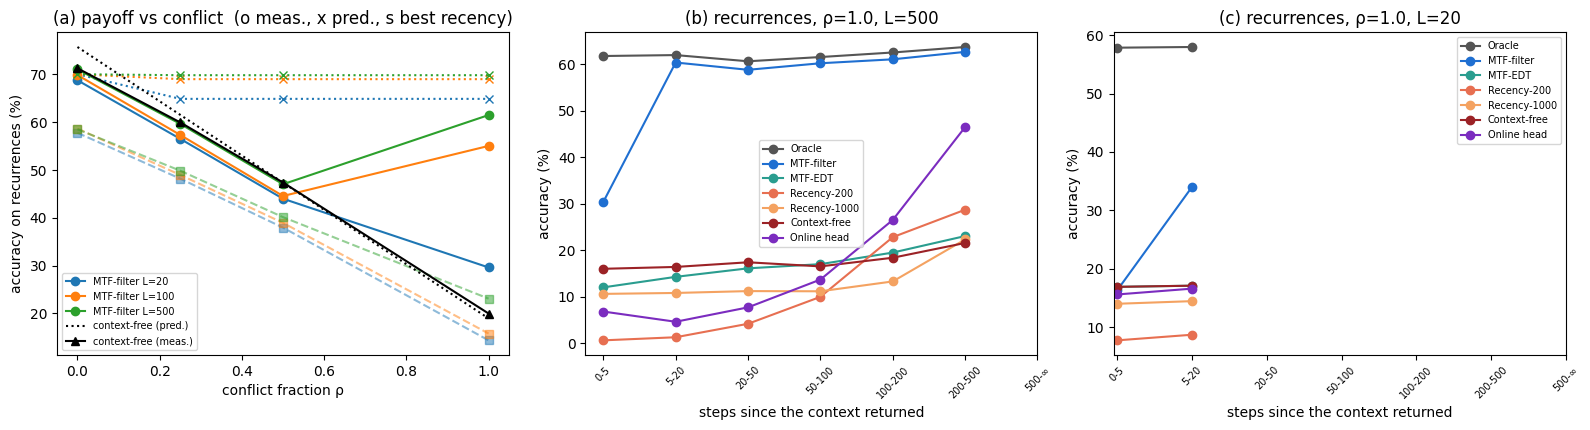

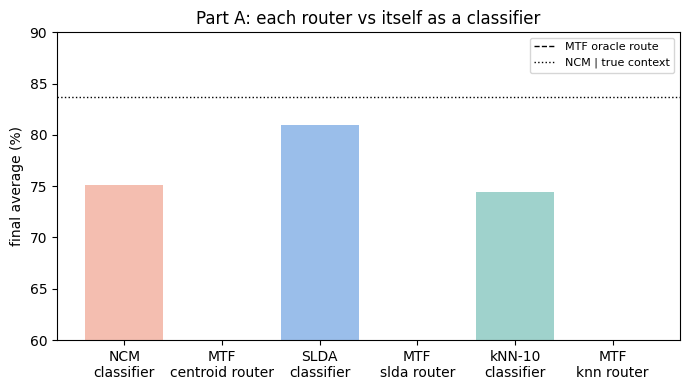

In [10]:
# ============================================================
# Cell 10: figures
# ============================================================
import matplotlib.pyplot as plt
COL = {'Oracle': '#555555', 'MTF-filter': '#1f6fd1', 'MTF-EDT': '#2a9d8f', 'MTF-EDT-grow': '#8ab17d',
       'MTF-noRecog': '#b5b5b5', 'Recency-200': '#e76f51', 'Recency-1000': '#f4a261',
       'Context-free': '#9b2226', 'Online head': '#7b2cbf'}
if RB:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    ax = axes[0]                                                 # payoff vs conflict
    for L in B_LS:
        xs, ym, yc, yp, yr = [], [], [], [], []
        for rho in B_RHOS:
            rs = [v for k, v in RB.items() if k.startswith(f'perm|{rho}|{L}|')]
            if not rs: continue
            xs.append(rho); ym.append(100*np.mean([r['arms']['MTF-filter']['recur'] for r in rs]))
            yc.append(100*np.mean([r['arms']['Context-free']['recur'] for r in rs]))
            yr.append(100*np.mean([max(r['arms']['Recency-200']['recur'], r['arms']['Recency-1000']['recur']) for r in rs]))
            yp.append(100*PRED['perm'][str(rho)]['mtf_recur'][str(L)])
        ax.plot(xs, ym, 'o-', label=f'MTF-filter L={L}'); ax.plot(xs, yp, 'x:', color=ax.lines[-1].get_color())
        ax.plot(xs, yr, 's--', color=ax.lines[-1].get_color(), alpha=.5)
    ax.plot(B_RHOS, [100*PRED['perm'][str(r)]['context_free'] for r in B_RHOS], 'k:', label='context-free (pred.)')
    ax.plot(xs, yc, 'k^-', label='context-free (meas.)')
    ax.set_xlabel('conflict fraction ρ'); ax.set_ylabel('accuracy on recurrences (%)')
    ax.set_title('(a) payoff vs conflict  (o meas., x pred., s best recency)'); ax.legend(fontsize=7)
    for j, (rho, L) in enumerate([(max(B_RHOS), max(B_LS)), (max(B_RHOS), min(B_LS))]):
        ax = axes[1 + j]; rs = [v for k, v in RB.items() if k.startswith(f'perm|{rho}|{L}|')]
        if not rs: continue
        mids = [f'{lo}-{hi if hi < 10**8 else "∞"}' for lo, hi in zip(BINS[:-1], BINS[1:])]
        for a in ['Oracle', 'MTF-filter', 'MTF-EDT', 'Recency-200', 'Recency-1000', 'Context-free', 'Online head']:
            c = [np.mean([r['arms'][a]['curve_recur'][i] for r in rs if r['arms'][a]['curve_recur'][i] is not None] or [np.nan])
                 for i in range(len(mids))]
            ax.plot(range(len(mids)), 100*np.array(c), 'o-', color=COL[a], label=a)
        ax.set_xticks(range(len(mids))); ax.set_xticklabels(mids, rotation=45, fontsize=7)
        ax.set_xlabel('steps since the context returned'); ax.set_ylabel('accuracy (%)')
        ax.set_title(f'({"bc"[j]}) recurrences, ρ={rho}, L={L}'); ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(os.path.join(OUT, 'partB_figure.png'), dpi=150); plt.show()
if RUN_PART_A and RA:
    fig, ax = plt.subplots(figsize=(7, 4))
    for rt, cl, c in [('centroid', 'NCM', '#e76f51'), ('slda', 'SLDA', '#1f6fd1'), ('knn', 'kNN-10', '#2a9d8f')]:
        m = [100*np.mean([r['final'][f'MTF[{rt}]'] for r in RA.values()])]; k = [100*np.mean([r['final'][f'clf[{cl}]'] for r in RA.values()])]
        ax.bar([f'{cl}\nclassifier'], k, color=c, alpha=.45); ax.bar([f'MTF\n{rt} router'], m, color=c)
    ax.axhline(100*np.mean([r['final']['MTF[oracle]'] for r in RA.values()]), ls='--', color='k', lw=1, label='MTF oracle route')
    ax.axhline(100*np.mean([r['final']['clf[NCM | true context]'] for r in RA.values()]), ls=':', color='k', lw=1, label='NCM | true context')
    ax.set_ylim(60, 90); ax.set_ylabel('final average (%)'); ax.set_title('Part A: each router vs itself as a classifier'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(OUT, 'partA_figure.png'), dpi=150); plt.show()

In [11]:
# ============================================================
# Cell 11: pre-registered checks (PASS/FAIL), written to checks.json
# ============================================================
checks = {}
if RUN_PART_A and RA:
    d = [abs(r['final']['MTF[slda]'] - r['final']['clf[SLDA]']) for r in RA.values()]
    checks['A1 |MTF[slda] - clf[SLDA]| <= 2 pts'] = bool(100*np.mean(d) <= 2)
    d = [r['final']['MTF[oracle]'] - r['final']['clf[NCM | true context]'] for r in RA.values()]
    checks['A2 MTF[oracle] - NCM|true ctx <= 3 pts'] = bool(100*np.mean(d) <= 3)
if RB:
    def mean_recur(kind, rho, L, arm):
        rs = [v for k, v in RB.items() if k.startswith(f'{kind}|{rho}|{L}|')]
        return np.mean([r['arms'][arm]['recur'] for r in rs]) if rs else None
    if 0.0 in B_RHOS:
        d = [abs(mean_recur('perm', 0.0, L, 'MTF-filter') - mean_recur('perm', 0.0, L, 'Context-free')) for L in B_LS]
        checks['B1 anchor: rho=0, |MTF-filter - context-free| <= 2 pts (all L)'] = bool(100*max(d) <= 2)
    rmax = max(B_RHOS)
    for L in [L for L in B_LS if L >= 100]:
        best_rec = max(mean_recur('perm', rmax, L, 'Recency-200'), mean_recur('perm', rmax, L, 'Recency-1000'))
        checks[f'B2 trap: rho={rmax}, L={L}: MTF-filter >= best recency + 5 pts'] = bool(
            100*(mean_recur('perm', rmax, L, 'MTF-filter') - best_rec) >= 5)
    for rho in B_RHOS:
        m = np.mean([mean_recur('perm', rho, L, 'Context-free') for L in B_LS])
        checks[f'B3 context-free <= predicted bound + 3 pts (rho={rho})'] = bool(100*(m - PRED['perm'][str(rho)]['context_free']) <= 3)
    if rmax > 0:
        ids = [v['route']['MTF-filter']['id_time_median'] for k, v in RB.items()
               if k.startswith(f'perm|{rmax}|') and v['route']['MTF-filter']['id_time_median'] is not None]
        ns = PRED['perm'][str(rmax)]['n_star']
        checks[f'B4 filter id-time within x3 of n*={ns:.1f} (rho={rmax})'] = bool(ids and np.median(ids) <= 3 * max(ns, 1))
    if min(B_LS) < 24:
        checks[f'B5 E-D-T predicted to fail at L={min(B_LS)}: MTF-EDT < MTF-filter - 5'] = bool(
            100*(mean_recur('perm', rmax, min(B_LS), 'MTF-EDT') - mean_recur('perm', rmax, min(B_LS), 'MTF-filter')) < -5)
for k, v in checks.items(): print(f'  {"PASS" if v else "FAIL"}  {k}')
save_json(checks, 'checks.json')

  FAIL  A1 |MTF[slda] - clf[SLDA]| <= 2 pts
  PASS  A2 MTF[oracle] - NCM|true ctx <= 3 pts
  PASS  B1 anchor: rho=0, |MTF-filter - context-free| <= 2 pts (all L)
  PASS  B2 trap: rho=1.0, L=100: MTF-filter >= best recency + 5 pts
  PASS  B2 trap: rho=1.0, L=500: MTF-filter >= best recency + 5 pts
  PASS  B3 context-free <= predicted bound + 3 pts (rho=0.0)
  PASS  B3 context-free <= predicted bound + 3 pts (rho=0.25)
  PASS  B3 context-free <= predicted bound + 3 pts (rho=0.5)
  PASS  B3 context-free <= predicted bound + 3 pts (rho=1.0)
  PASS  B4 filter id-time within x3 of n*=1.5 (rho=1.0)
  PASS  B5 E-D-T predicted to fail at L=20: MTF-EDT < MTF-filter - 5
